<a href="https://colab.research.google.com/github/click2shivesh/shivesh-uta-aiml-py/blob/main/Shivesh_INN_ReneWind_Neural_Networks_Full_Code_Notebook_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ReneWind Neural Networks Project - Full Code Solution

## Business Context
Renewable energy is becoming increasingly important as organisations work to reduce the environmental impact of energy production. Wind energy is one of the most mature renewable energy technologies, and predictive maintenance is a key lever for reducing turbine downtime and maintenance cost.

In this project, ReneWind wants to use sensor data from wind turbine generators to predict generator failures before they happen. Early detection allows the business to inspect or repair components before a breakdown occurs.

## Objective
The objective is to build, tune, and compare Neural Network classification models that can identify generator failures.

The business interpretation of model outcomes is:

- **True Positive (TP):** Actual failure correctly detected. This leads to repair cost.
- **False Negative (FN):** Actual failure missed by the model. This leads to replacement cost and is the most expensive error.
- **False Positive (FP):** Failure predicted, but no actual failure occurred. This leads to inspection cost.
- **True Negative (TN):** No failure correctly predicted.

Since replacement cost is higher than repair cost, and repair cost is higher than inspection cost, the model should focus on reducing **False Negatives**. Therefore, **Recall for the failure class (`Target = 1`)** will be treated as the primary evaluation metric, supported by F1-score, Precision, ROC-AUC, PR-AUC, and confusion matrix analysis.

# Installing and Importing the Necessary Libraries

In [1]:
# Installing the libraries with the specified versions
# Run this cell in Google Colab if the required versions are not already available.
# After installation, restart the runtime and run the notebook sequentially from the next cell.

!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib==3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.4 MB/s eta 0:00:00


In [2]:
# Importing libraries for data manipulation and numerical computation
import numpy as np
import pandas as pd

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing preprocessing and model selection utilities
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Importing model evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Importing TensorFlow/Keras libraries for Neural Network modeling
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppressing unnecessary warnings for a cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# Setting display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Setting random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Loading the Data

In [3]:
# Mounting Google Drive to access the project datasets
# Skip this cell if running locally and update the file paths accordingly.
from google.colab import drive
drive.mount('/content/drive')

# Defining file paths for train and test datasets
train_path = "/content/drive/MyDrive/AIML-UTA-PY/Train.csv"
test_path  = "/content/drive/MyDrive/AIML-UTA-PY/Test.csv"

# Loading the datasets
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# Displaying the dimensions of both datasets
train_df.shape, test_df.shape

Mounted at /content/drive


((20000, 41), (5000, 41))

### Observations

- The training dataset contains **20,000 observations and 41 columns**.
- The test dataset contains **5,000 observations and 41 columns**.
- Both datasets have the same structure, which means they contain the same predictor variables and the target variable.
- As per the problem statement, there are **40 anonymized sensor predictors** and **1 binary target variable**.
- The target variable is `Target`, where `1` represents generator failure and `0` represents no failure.

# Data Overview

In [4]:
# Displaying the first five observations from the training data
train_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.4646,-4.6791,3.1015,0.5061,-0.2211,-2.0325,-2.9109,0.0507,-1.5224,3.7619,-5.7147,0.7359,0.9813,1.4179,-3.3758,-3.0473,0.3062,2.9141,2.2700,4.3949,-2.3883,0.6464,-1.1905,3.1330,0.6653,-2.5108,-0.0367,0.7262,-3.9822,-1.0726,1.6671,3.0597,-1.6904,2.8463,2.2352,6.6675,0.4438,-2.3692,2.9506,-3.4803,0
1,3.3659,3.6534,0.9097,-1.3675,0.3320,2.3589,0.7326,-4.3321,0.5657,-0.1011,1.9145,-0.9515,-1.2553,-2.7065,0.1932,-4.7694,-2.2053,0.9077,0.7569,-5.8337,-3.0651,1.5966,-1.7573,1.7664,-0.2671,3.6250,1.5003,-0.5857,0.7830,-0.2012,0.0249,-1.7955,3.0328,-2.4675,1.8946,-2.2978,-1.7310,5.9088,-0.3863,0.6162,0
2,-3.8318,-5.8244,0.6340,-2.4188,-1.7738,1.0168,-2.0989,-3.1732,-2.0819,5.3926,-0.7707,1.1067,1.1443,0.9433,-3.1638,-4.2478,-4.0389,3.6885,3.3112,1.0590,-2.1430,1.6501,-1.6606,1.6799,-0.4508,-4.5507,3.7388,1.1344,-2.0335,0.8408,-1.6004,-0.2571,0.8035,4.0862,2.2921,5.3608,0.3520,2.9400,3.8392,-4.3094,0
3,1.6181,1.8883,7.0461,-1.1473,0.0831,-1.5298,0.2073,-2.4936,0.3449,2.1186,-3.0530,0.4597,2.7045,-0.6361,-0.4537,-3.1740,-3.4043,-1.2815,1.5821,-1.9518,-3.5166,-1.2060,-5.6279,-1.8177,2.1241,5.2946,4.7481,-2.3085,-3.9630,-6.0287,4.9488,-3.5844,-2.5775,1.3638,0.6227,5.5501,-1.5268,0.1389,3.1014,-1.2774,0
4,-0.1114,3.8725,-3.7584,-2.9829,3.7927,0.5450,0.2054,4.8490,-1.8549,-6.2200,1.9983,4.7238,0.7091,-1.9894,-2.6327,4.1844,2.2454,3.7345,-6.3128,-5.3799,-0.8867,2.0617,9.4456,4.4900,-3.9451,4.5821,-8.7804,-3.3830,5.1065,6.7875,2.0442,8.2659,6.6292,-10.0687,1.2230,-3.2298,1.6869,-2.1639,-3.6446,6.5103,0


In [5]:
# Displaying the first five observations from the test data
test_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.6135,-3.8196,2.2023,1.3004,-1.1849,-4.4960,-1.8358,4.7230,1.2061,-0.3419,-5.1229,1.0170,4.8185,3.2690,-2.9843,1.3874,2.0320,-0.5116,-1.0231,7.3387,-2.2422,0.1555,2.0538,-2.7723,1.8514,-1.7887,-0.2773,-1.2551,-3.8329,-1.5045,1.5868,2.2912,-5.4114,0.8701,0.5745,4.1572,1.4281,-10.5113,0.4547,-1.4484,0
1,0.3896,-0.5123,0.5271,-2.5768,-1.0168,2.2351,-0.4413,-4.4057,-0.3329,1.9668,1.7965,0.4105,0.6383,-1.3896,-1.8834,-5.0179,-3.8272,2.4181,1.7623,-3.2423,-3.1930,1.8575,-1.7080,0.6334,-0.5879,0.0837,3.0139,-0.1823,0.2239,0.8652,-1.7822,-2.4749,2.4936,0.3152,2.0593,0.6839,-0.4855,5.1284,1.7207,-1.4882,0
2,-0.8749,-0.6406,4.0842,-1.5905,0.5259,-1.9576,-0.6954,1.3473,-1.7323,0.4665,-4.9282,3.5651,-0.4493,-0.6562,-0.1665,-1.6302,2.2919,2.3965,0.6013,1.7935,-2.1202,0.4820,-0.8407,1.7902,1.8744,0.3639,-0.1691,-0.4838,-2.1190,-2.1566,2.9073,-1.3189,-2.9975,0.4597,0.6198,5.6315,1.3235,-1.7522,1.8083,1.6757,0
3,0.2384,1.4586,4.0145,2.5345,1.1970,-3.1173,-0.9240,0.2695,1.3224,0.7023,-5.5783,-0.8507,2.5905,0.7674,-2.3908,-2.3420,0.5719,-0.9338,0.5087,1.2107,-3.2595,0.1046,-0.6589,1.4981,1.1003,4.1430,-0.2484,-1.1365,-5.3558,-4.5459,3.8087,3.5179,-3.0741,-0.2842,0.9546,3.0293,-1.3672,-3.4121,0.9060,-2.4509,0
4,5.8282,2.7683,-1.2345,2.8093,-1.6416,-1.4067,0.5686,0.9650,1.9184,-2.7749,-0.5300,1.3745,-0.6509,-1.6795,-0.3792,-4.4431,3.8939,-0.6076,2.9449,0.3672,-5.7891,4.5975,4.4503,3.2249,0.3967,0.2478,-2.3620,1.0794,-0.4731,2.2428,-3.5914,1.7738,-1.5016,-2.2267,4.7768,-6.5597,-0.8056,-0.2760,-3.8582,-0.5377,0


### Observations

- The predictor variables are named `V1` to `V40`, indicating that the actual sensor names have been anonymized due to confidentiality.
- All predictors appear to be numerical, which makes the data suitable for Neural Network modeling.
- Since the variables are ciphered, individual feature-level business interpretation is limited.
- The focus of the project will therefore be on model performance, cost-sensitive error reduction, and operational recommendations.

In [6]:
# Checking the structure of the training dataset
# This helps identify data types, number of columns, and non-null values.
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

### Observations

- The dataset contains **40 predictor variables** and **1 target variable**.
- All predictor variables are numerical and stored as `float64`.
- The target variable is stored as `int64`.
- Variables `V1` and `V2` contain a small number of missing values.
- Neural Networks are sensitive to feature scale, so feature standardization will be required before model training.

In [7]:
# Generating summary statistics for numerical variables
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0000,-0.2720,3.4416,-11.8765,-2.7371,-0.7479,1.8401,15.4930
V2,19982.0000,0.4404,3.1508,-12.3200,-1.6407,0.4715,2.5440,13.0893
V3,20000.0000,2.4847,3.3890,-10.7081,0.2069,2.2558,4.5662,17.0909
V4,20000.0000,-0.0832,3.4316,-15.0821,-2.3477,-0.1352,2.1306,13.2364
V5,20000.0000,-0.0538,2.1048,-8.6034,-1.5356,-0.1020,1.3405,8.1338
V6,20000.0000,-0.9954,2.0410,-10.2271,-2.3472,-1.0005,0.3803,6.9758
V7,20000.0000,-0.8793,1.7616,-7.9497,-2.0309,-0.9172,0.2237,8.0061
V8,20000.0000,-0.5482,3.2958,-15.6576,-2.6427,-0.3891,1.7230,11.6795
V9,20000.0000,-0.0168,2.1606,-8.5963,-1.4950,-0.0676,1.4092,8.1376
V10,20000.0000,-0.0130,2.1932,-9.8540,-1.4112,0.1010,1.4770,8.1085


### Observations

- The predictors have different ranges and scales.
- Some variables contain negative values, while others have relatively large positive values.
- The difference in scale confirms that feature standardization is necessary before training Neural Networks.
- Some variables show wide gaps between minimum and maximum values, suggesting possible outliers or transformed sensor extremes.
- Since the variables are anonymized sensor readings, outliers will not be removed directly unless there is strong evidence that they are data errors.

# Exploratory Data Analysis

The EDA focuses on missing values, duplicate records, class distribution, feature distributions, and relationships between predictors and the target variable.

## Missing Value Analysis

In [8]:
# Checking the number and percentage of missing values in the training data
missing_train = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_train[missing_train["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
V1,18,0.0900
V2,18,0.0900


In [9]:
# Checking the number and percentage of missing values in the test data
missing_test = pd.DataFrame({
    "Missing Count": test_df.isnull().sum(),
    "Missing Percentage": (test_df.isnull().sum() / len(test_df)) * 100
})

missing_test[missing_test["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
V2,6,0.1200
V1,5,0.1000


### Observations

- Missing values are present only in `V1` and `V2`.
- The missing value percentage is extremely small in both training and test datasets.
- Since the variables are numerical, median imputation is a suitable approach.
- Median imputation is preferred over mean imputation because it is more robust to extreme values.
- To avoid data leakage, the imputer will be fitted only on the training subset after the train-validation split, and then applied to validation and test data.

## Duplicate Value Analysis

In [10]:
# Checking duplicate observations in train and test datasets
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in test data:", test_df.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


### Observations

- No duplicate records are present in either the training dataset or the test dataset.
- Therefore, no duplicate treatment is required.

## Univariate Analysis

In [11]:
# Checking the count and percentage distribution of the target variable
target_distribution = pd.DataFrame({
    "Count": train_df["Target"].value_counts(),
    "Percentage": train_df["Target"].value_counts(normalize=True) * 100
})

target_distribution

,Count,Percentage
Target,,
0,18890,94.4500
1,1110,5.5500


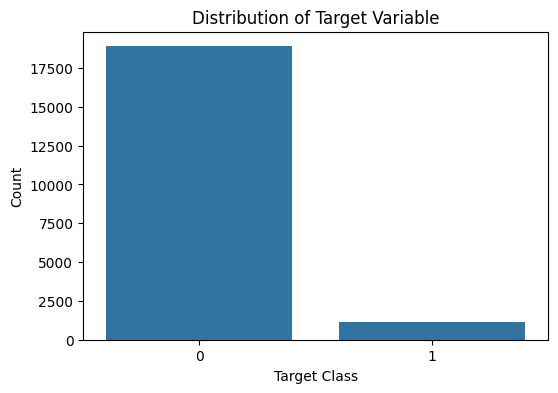

In [12]:
# Visualizing the class distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=train_df)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

### Observations

- The target variable is highly imbalanced.
- The majority class is `Target = 0`, representing no generator failure.
- The minority class is `Target = 1`, representing generator failure.
- Failure cases account for only around **5.5%** of the training observations.
- Since failures are rare but expensive to miss, accuracy alone is not a suitable metric.
- The model should prioritise **Recall for class 1**, because a missed failure can lead to expensive generator replacement.

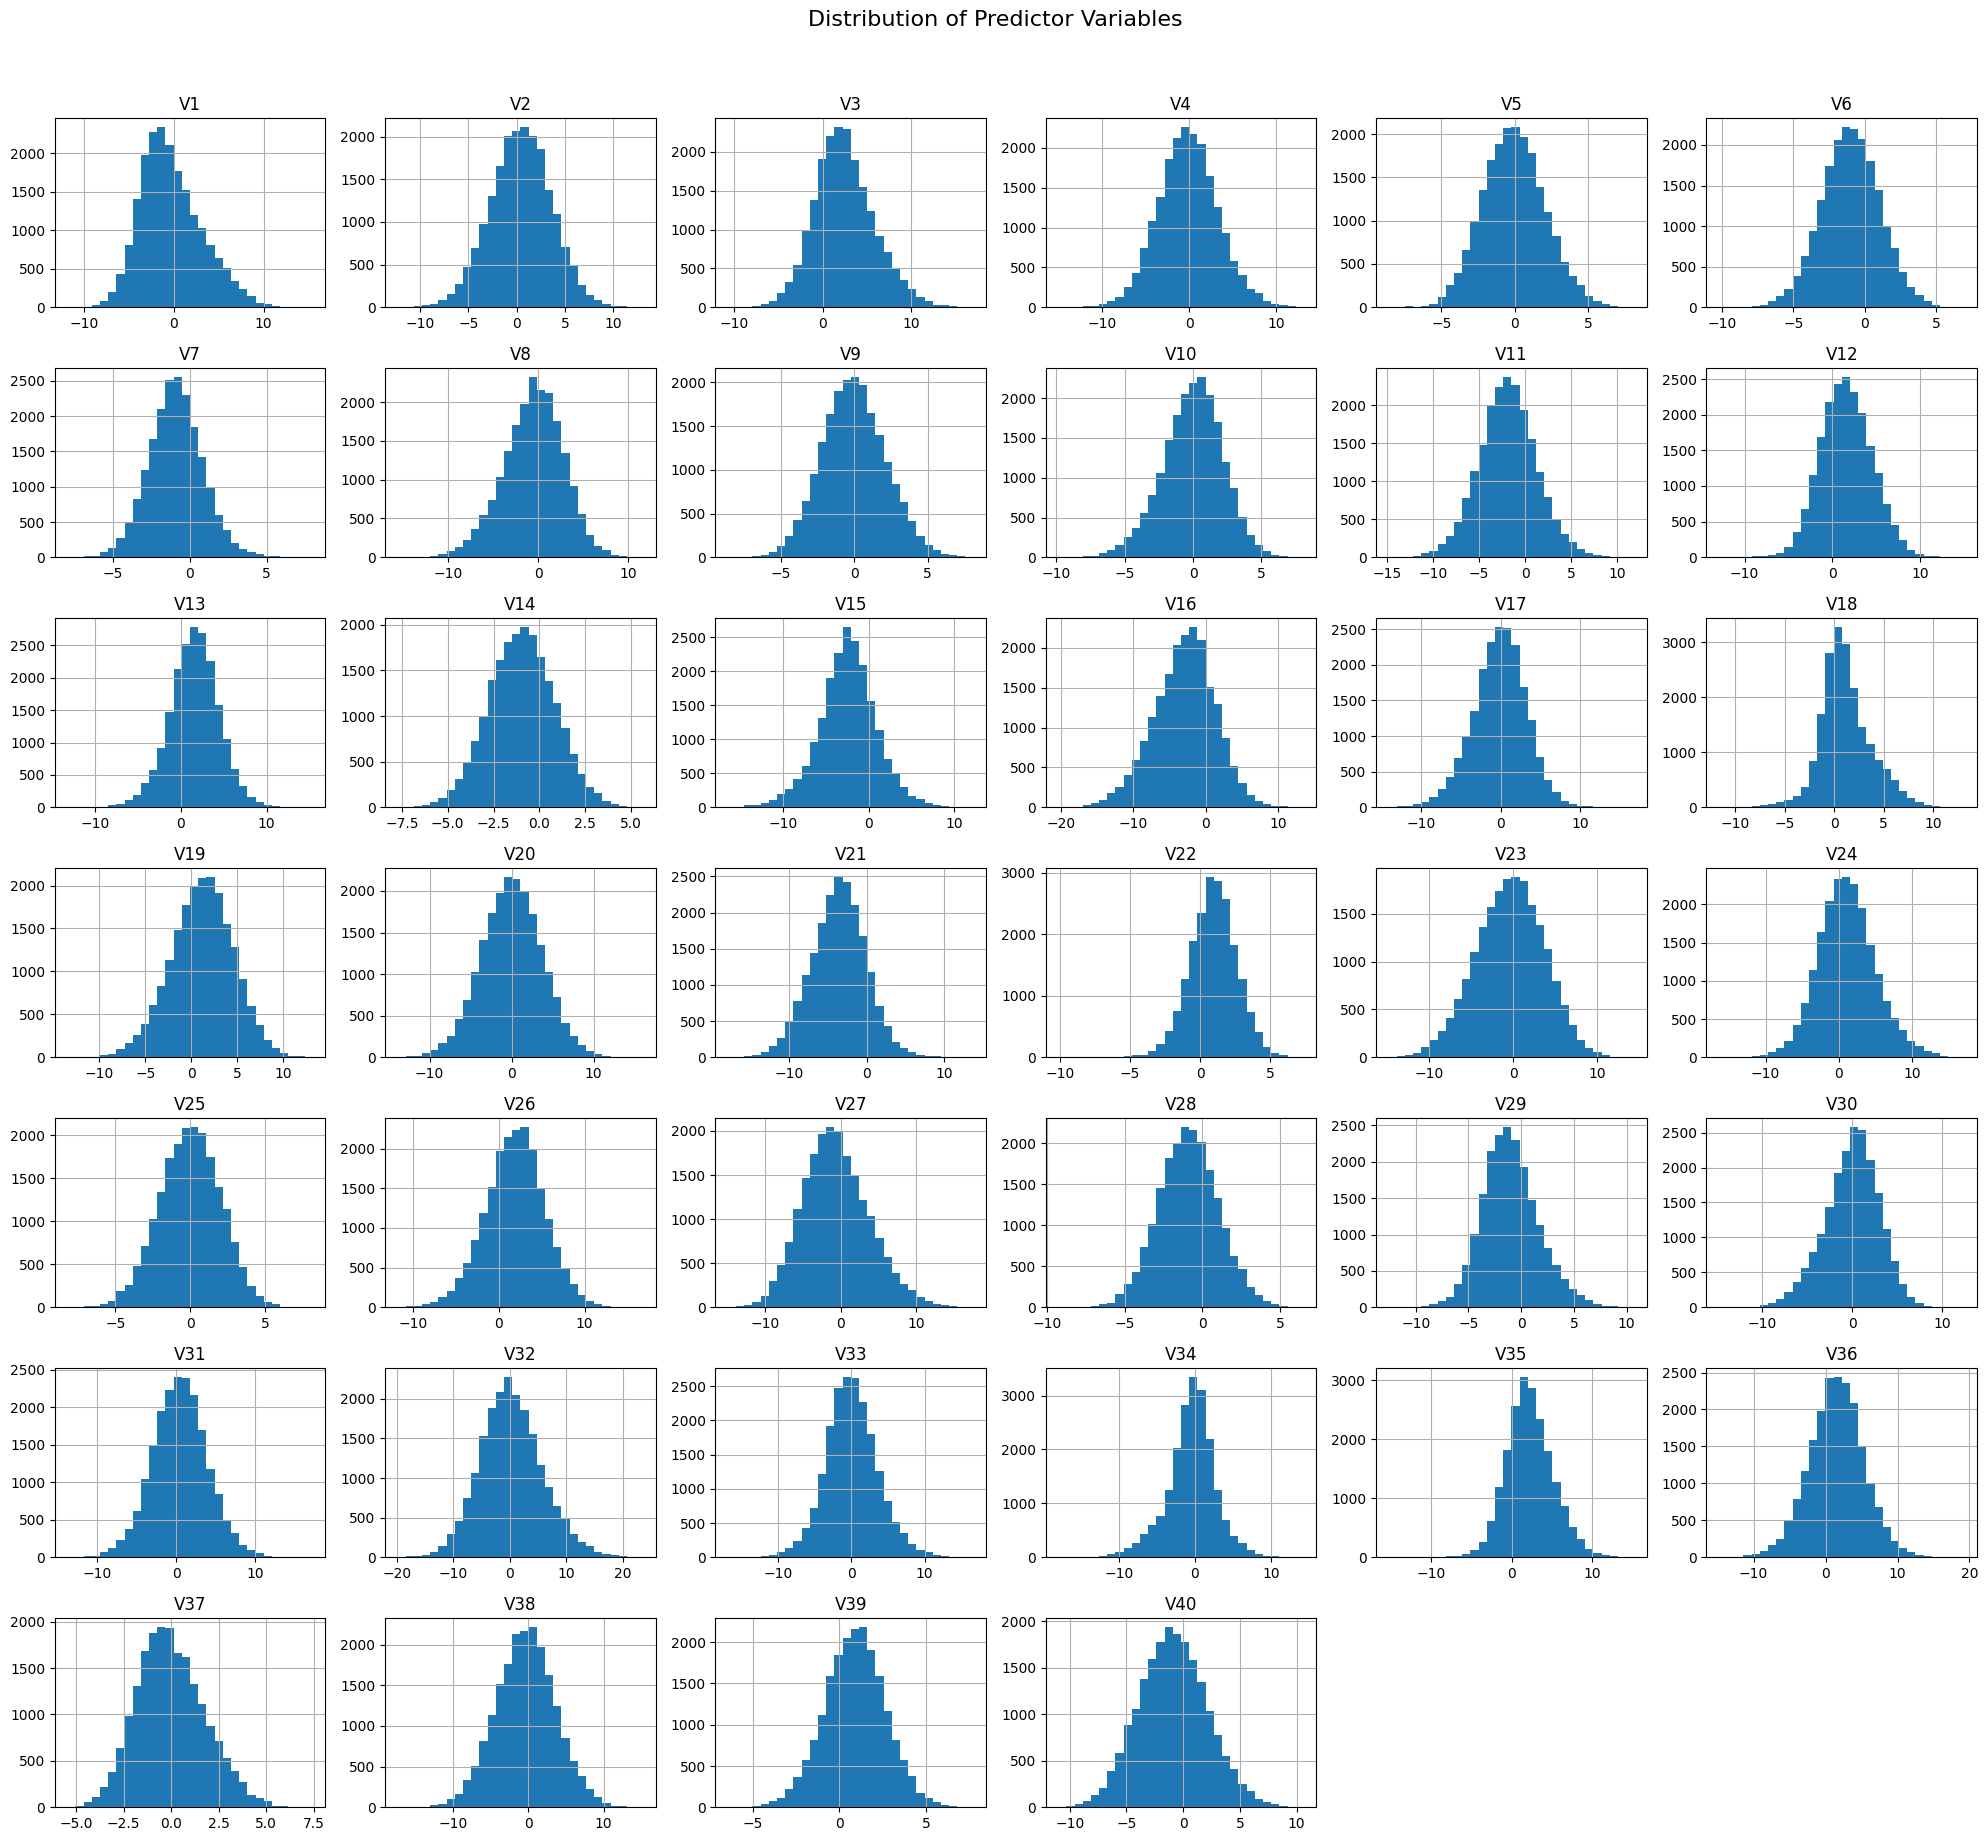

In [13]:
# Separating predictor columns for visualization
predictor_cols = [col for col in train_df.columns if col != "Target"]

# Plotting histograms for all predictor variables to understand their distributions
train_df[predictor_cols].hist(figsize=(20, 18), bins=30)
plt.suptitle("Distribution of Predictor Variables", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Generic Observations for Predictor Distributions

- All predictor variables are numerical and appear to be transformed sensor readings.
- Several predictors are approximately centered around zero, while some variables have wider ranges.
- The feature distributions are not identical, which is expected because they may represent different turbine sensors or transformed measurements.
- Neural Networks benefit from scaled inputs, so standardization will be applied before model building.

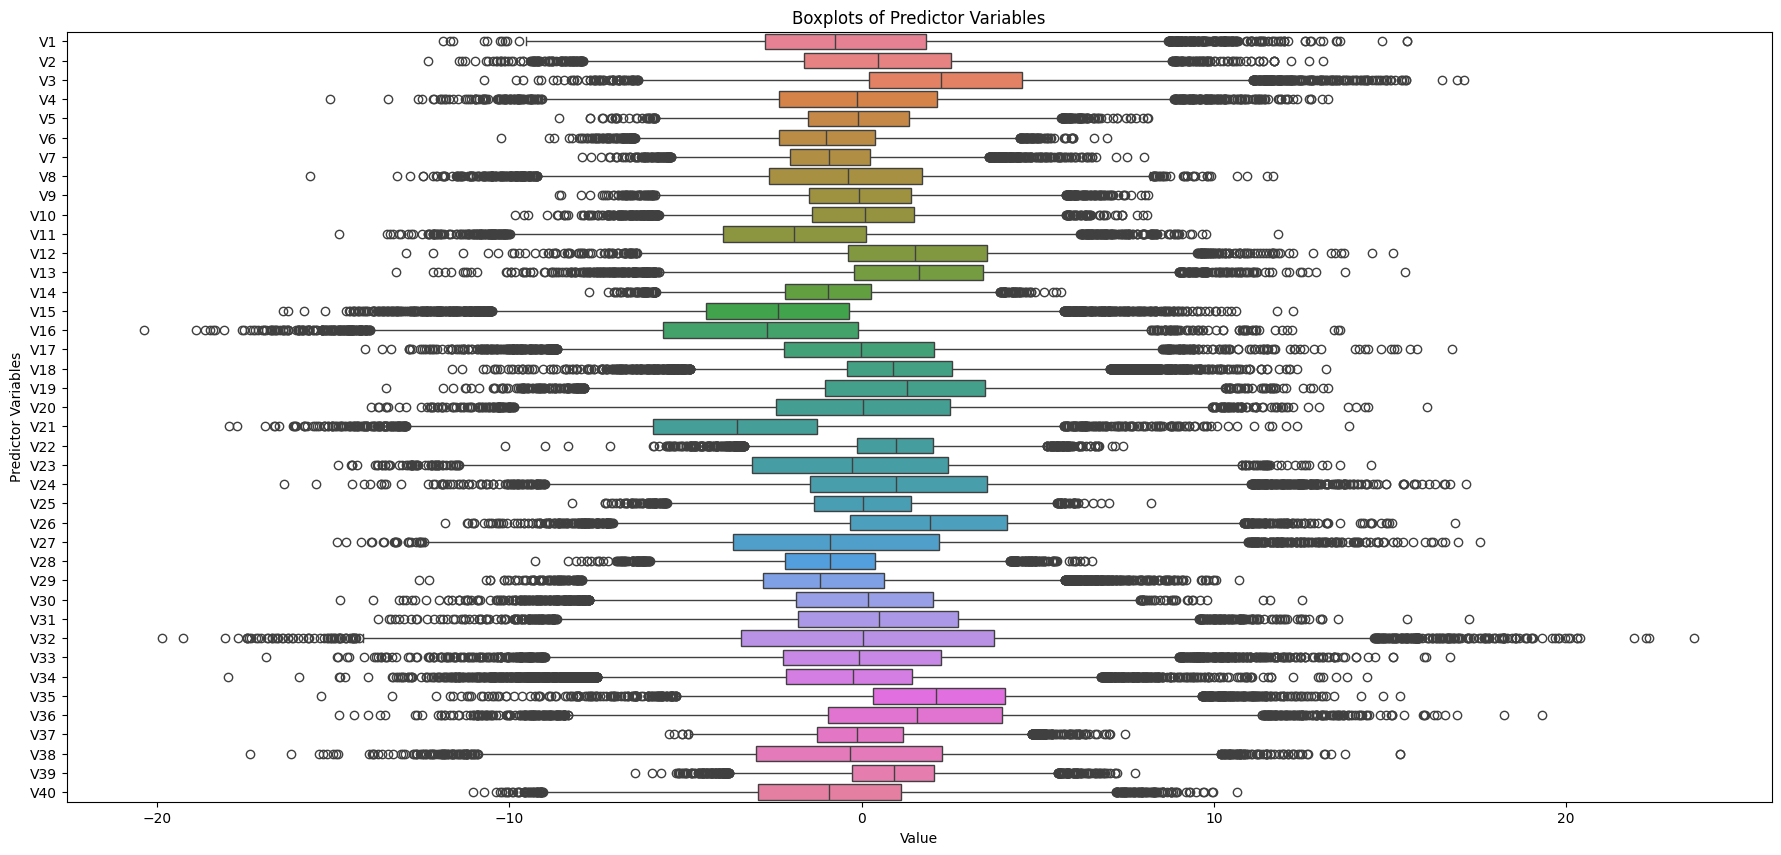

In [14]:
# Visualizing boxplots for all predictor variables to check spread and possible outliers
plt.figure(figsize=(22, 10))
sns.boxplot(data=train_df[predictor_cols], orient="h")
plt.title("Boxplots of Predictor Variables")
plt.xlabel("Value")
plt.ylabel("Predictor Variables")
plt.show()

### Observations

- Some variables show a wide spread and potential outliers.
- Since the predictors are anonymized sensor readings, these extreme values may represent valid operating conditions rather than data errors.
- The outliers will not be removed at this stage to avoid losing potentially important failure signals.
- Scaling will help reduce the effect of different feature magnitudes during Neural Network training.

## Bivariate Analysis

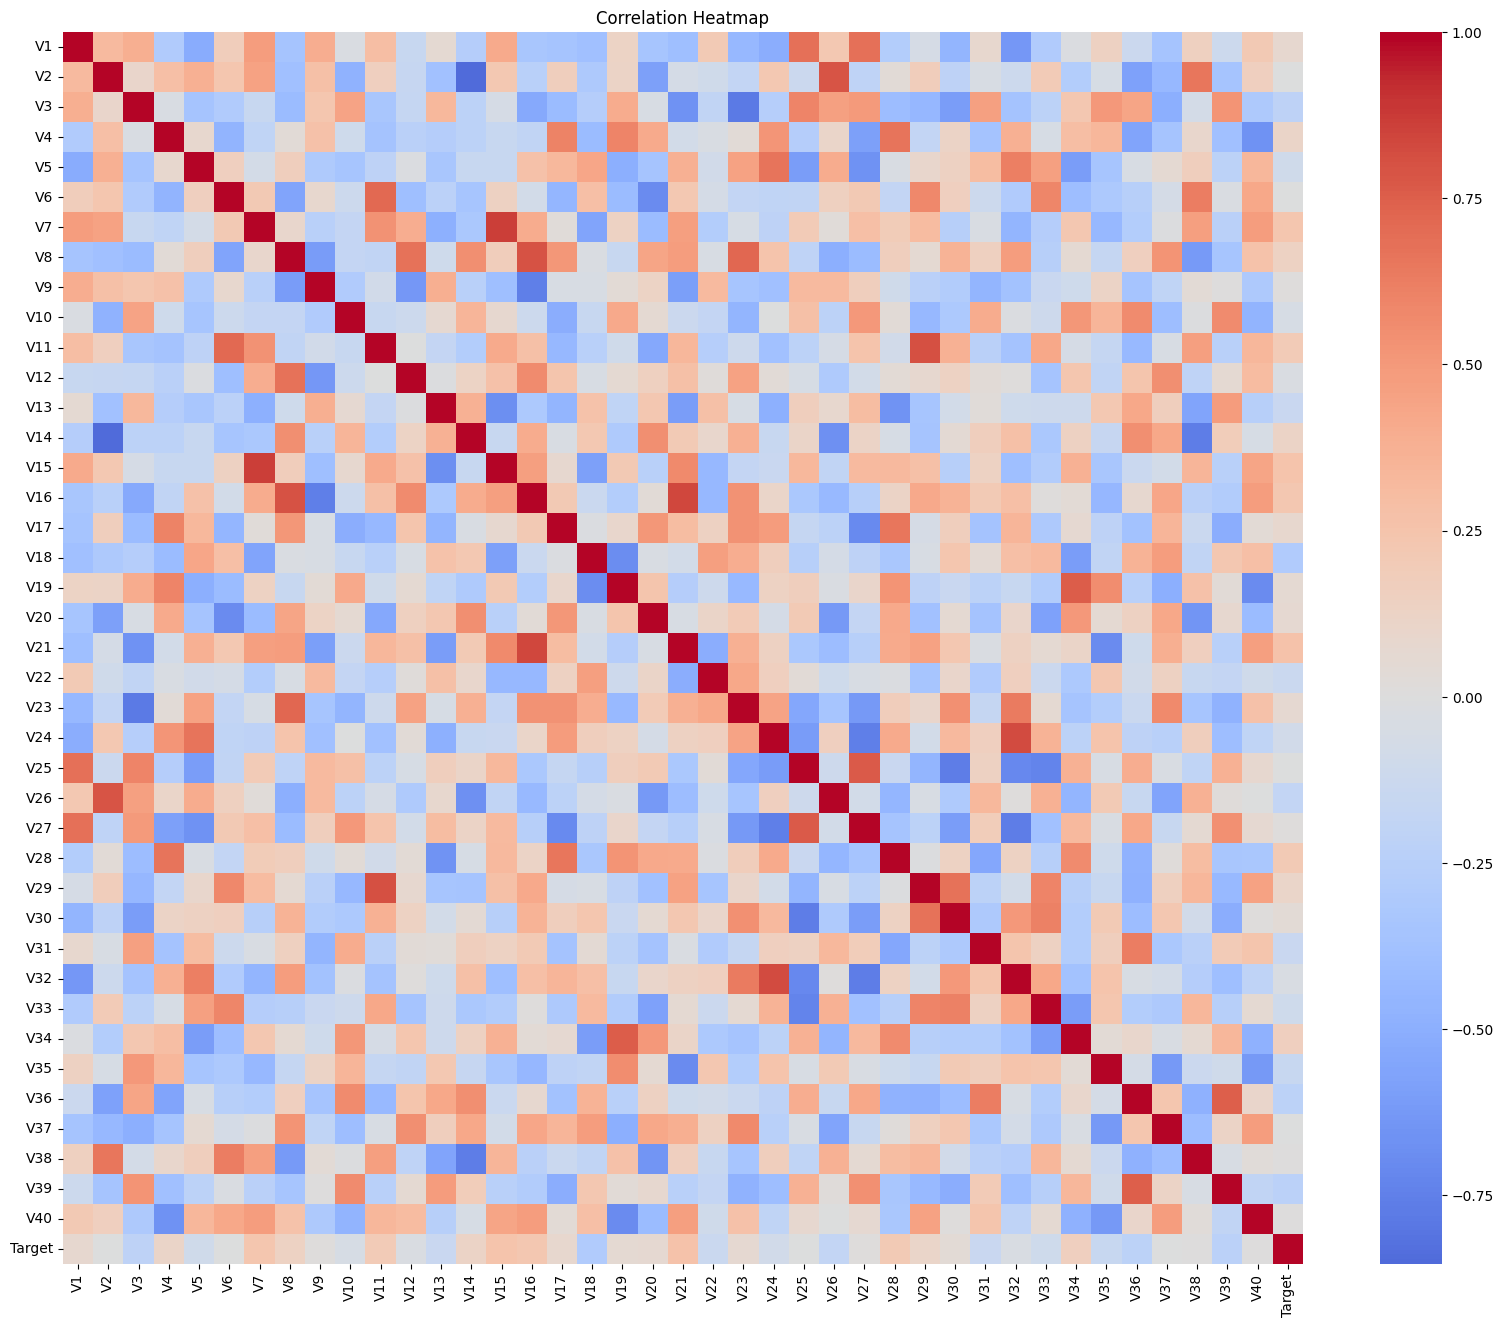

In [15]:
# Computing correlation matrix
corr_matrix = train_df.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Observations

- The heatmap helps identify relationships among predictor variables and between predictors and the target.
- Since the variables are anonymized, correlation analysis is mainly useful for understanding statistical relationships rather than direct business interpretation.
- Strongly correlated predictors may carry overlapping information, but Neural Networks can generally handle correlated inputs.
- No feature will be removed based only on correlation because the dataset has a manageable number of predictors and the model may learn useful nonlinear relationships.

In [16]:
# Checking correlation of predictor variables with the target variable
corr_with_target = corr_matrix["Target"].drop("Target").sort_values(ascending=False)

# Displaying the top positively and negatively correlated features with the target
print("Top 10 positively correlated features with Target:")
display(corr_with_target.head(10))

print("\nTop 10 negatively correlated features with Target:")
display(corr_with_target.tail(10))

Top 10 positively correlated features with Target:


,Target
V21,0.2564
V15,0.2491
V7,0.2369
V16,0.2305
V28,0.2074
V11,0.1967
V34,0.1539
V8,0.1360
V14,0.1176
V4,0.1108



Top 10 negatively correlated features with Target:


,Target
V33,-0.1025
V22,-0.1347
V31,-0.1370
V13,-0.1397
V35,-0.1456
V26,-0.1805
V3,-0.2139
V36,-0.2165
V39,-0.2273
V18,-0.2933


In [17]:
# Selecting top features based on absolute correlation with target
important_features = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()
important_features

['V18', 'V21', 'V15', 'V7', 'V16', 'V39', 'V36', 'V3']

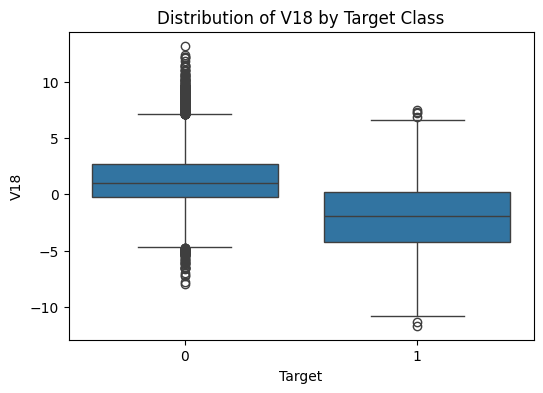

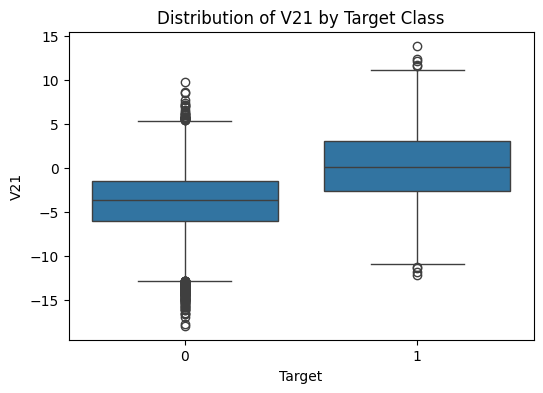

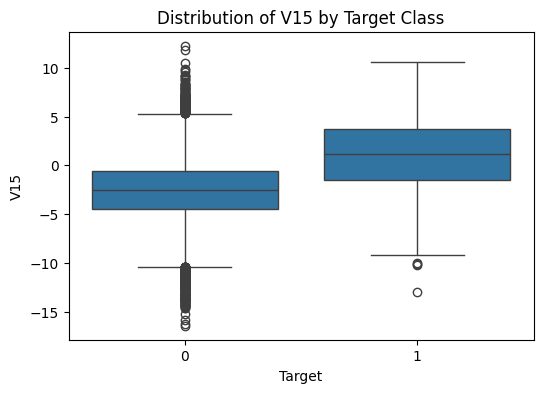

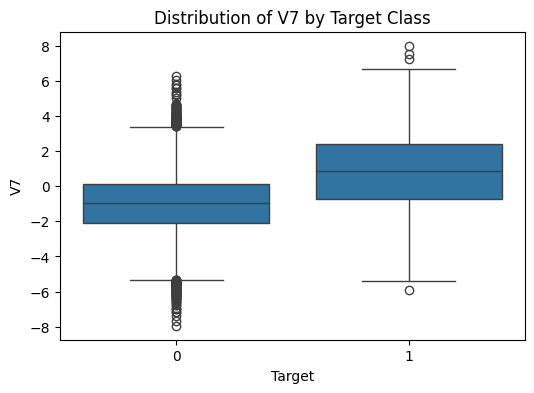

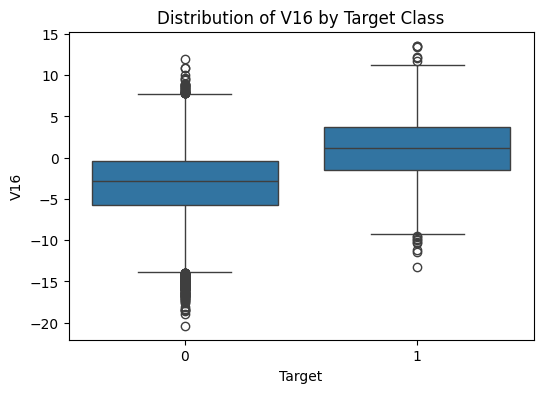

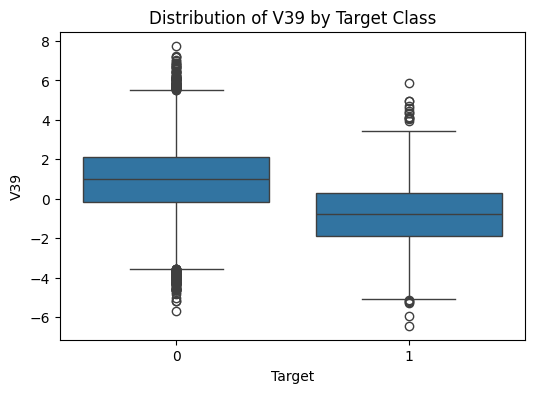

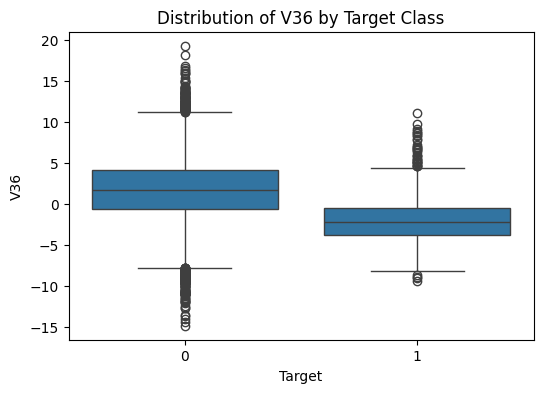

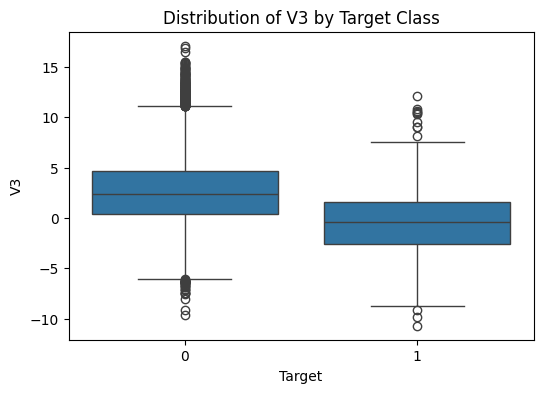

In [18]:
# Comparing the distribution of the most target-correlated features across target classes
for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Target", y=col, data=train_df)
    plt.title(f"Distribution of {col} by Target Class")
    plt.show()

### Observations

- The selected features show some distributional differences across failure and non-failure classes.
- These differences suggest that the sensor readings contain predictive signals for generator failure.
- However, the separation between the two classes is not expected to be perfectly linear, so Neural Networks are suitable because they can capture nonlinear relationships.

# Data Preprocessing

In [19]:
# Separating predictors and target variable
X = train_df.drop("Target", axis=1)
y = train_df["Target"]

X_test_final = test_df.drop("Target", axis=1)
y_test_final = test_df["Target"]

# Splitting the original training data into training and validation subsets
# Stratification preserves the minority failure class ratio in both subsets.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training subset shape:", X_train.shape)
print("Validation subset shape:", X_val.shape)
print("Final test set shape:", X_test_final.shape)

Training subset shape: (16000, 40)
Validation subset shape: (4000, 40)
Final test set shape: (5000, 40)


In [20]:
# Checking target distribution after stratified split
print("Training target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation target distribution (%):")
print((y_val.value_counts(normalize=True) * 100).round(2))

Training target distribution (%):
Target
0   94.4500
1    5.5500
Name: proportion, dtype: float64

Validation target distribution (%):
Target
0   94.4500
1    5.5500
Name: proportion, dtype: float64


In [21]:
# Applying median imputation
# The imputer is fitted only on X_train to avoid data leakage.
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test_final)

# Applying feature scaling
# The scaler is also fitted only on X_train to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [22]:
# Computing class weights to handle class imbalance during model training
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

class_weights

{np.int64(0): np.float64(0.5293806246691372),
 np.int64(1): np.float64(9.00900900900901)}

### Observations

- The data was split into training and validation subsets using stratification to preserve the failure class ratio.
- Median imputation was applied to treat missing values in `V1` and `V2`.
- Both imputation and scaling were fitted only on the training subset to avoid data leakage.
- Standardization was applied because Neural Networks are sensitive to feature scale.
- Class weights were calculated to give more importance to the minority failure class during selected model training experiments.

# Model Building

## Model Evaluation Criterion

For this predictive maintenance problem, the most important business risk is missing a real generator failure.

- A **False Negative** means the model failed to detect an actual failure. This may lead to generator breakdown and replacement cost.
- A **False Positive** means the model predicted a failure when there was none. This leads to inspection cost, which is less expensive than replacement.

Therefore, the primary metric is:

### Recall for class 1

Recall measures how many actual failures were correctly identified by the model.

Supporting metrics used for comparison:

- Precision for class 1
- F1-score for class 1
- ROC-AUC
- PR-AUC
- Confusion matrix

The final model should provide high recall while maintaining a reasonable balance with precision, so that the business can detect most failures without creating excessive unnecessary inspections.

In [23]:
# Helper function to build a Neural Network model with flexible architecture

def build_nn_model(
    input_dim,
    hidden_layers=[64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
):
    # Builds and compiles a feed-forward Neural Network for binary classification.
    model = Sequential()

    # Adding the first hidden layer with input dimension
    model.add(Dense(hidden_layers[0], activation="relu", input_shape=(input_dim,)))
    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    # Adding remaining hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        if batch_norm:
            model.add(BatchNormalization())
        if dropout_rate is not None:
            model.add(Dropout(dropout_rate))

    # Output layer for binary classification
    model.add(Dense(1, activation="sigmoid"))

    # Selecting optimizer
    if optimizer.lower() == "sgd":
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == "adam":
        opt = Adam(learning_rate=learning_rate)
    else:
        raise ValueError("optimizer must be either 'sgd' or 'adam'")

    # Compiling the model
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [24]:
# Helper function to evaluate model performance

def evaluate_model(model, X_data, y_true, model_name, threshold=0.50):
    # Evaluates a trained model and returns key classification metrics.
    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_1": precision_score(y_true, y_pred, zero_division=0),
        "Recall_1": recall_score(y_true, y_pred, zero_division=0),
        "F1_1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

    return metrics, y_pred, y_prob


def print_detailed_evaluation(model, X_data, y_true, model_name, threshold=0.50):
    # Prints confusion matrix and classification report for a model.
    metrics, y_pred, y_prob = evaluate_model(model, X_data, y_true, model_name, threshold)

    print(f"Model: {model_name}")
    print(f"Decision Threshold: {threshold}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("\nKey Metrics:")
    for key, value in metrics.items():
        if key not in ["Model"]:
            print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

    return metrics


def plot_training_history(history, title):
    # Plots training and validation loss and recall curves.
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "recall" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["recall"], label="Train Recall")
        plt.plot(history_df["val_recall"], label="Validation Recall")
        plt.title(f"{title} - Recall Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Recall")
        plt.legend()
        plt.show()


def model_observation(metrics):
    # Prints automated business-focused observations for a model.
    recall = metrics["Recall_1"]
    precision = metrics["Precision_1"]
    f1 = metrics["F1_1"]
    pr_auc = metrics["PR_AUC"]

    print("Automated Observation:")
    print(f"- The model achieved recall of {recall:.4f} for the failure class.")
    print(f"- Precision for the failure class is {precision:.4f}, indicating the reliability of failure alerts.")
    print(f"- F1-score is {f1:.4f}, showing the balance between recall and precision.")
    print(f"- PR-AUC is {pr_auc:.4f}, which is important for imbalanced classification problems.")

    if recall >= 0.80:
        print("- From a predictive maintenance perspective, this model is strong at identifying actual failures.")
    elif recall >= 0.60:
        print("- The model captures a reasonable proportion of failures, but further improvement is desirable.")
    else:
        print("- The model misses a large proportion of failures and is not ideal for deployment without improvement.")

In [25]:
# Defining callbacks to prevent overfitting and improve convergence
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Storing validation results for model comparison
validation_results = []
training_results = []

# Initial Model Building and Model Performance Improvement

## Model 0 - Baseline Neural Network with SGD

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9181 - auc: 0.5326 - loss: 0.3057 - pr_auc: 0.0560 - precision: 0.0413 - recall: 0.0214 - val_accuracy: 0.9445 - val_auc: 0.7053 - val_loss: 0.2075 - val_pr_auc: 0.1758 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9459 - auc: 0.8103 - loss: 0.1799 - pr_auc: 0.3942 - precision: 1.0000 - recall: 0.0259 - val_accuracy: 0.9485 - val_auc: 0.8304 - val_loss: 0.1670 - val_pr_auc: 0.5279 - val_precision: 1.0000 - val_recall: 0.0721 - learning_rate: 0.0100
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9554 - auc: 0.8694 - loss: 0.1498 - pr_auc: 0.5835 - precision: 0.9833 - recall: 0.1993 - val_accuracy: 0.9588 - val_auc: 0.8649 - val_loss: 0.1452 - val_pr_auc: 0.6243 - val_precision: 1.0000 - val_recall: 0.2568 - learning_rate: 0.0100
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9616 - auc: 0.

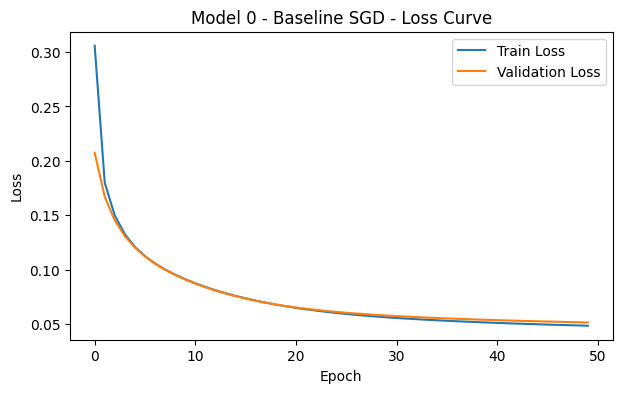

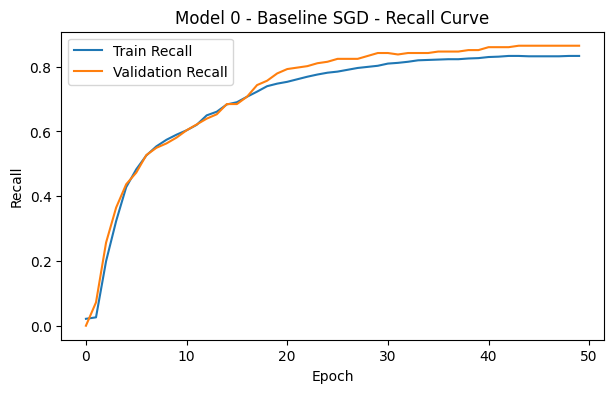

Model: Model 0 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15100    12]
 [  144   744]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9906    0.9992    0.9949     15112
           1     0.9841    0.8378    0.9051       888

    accuracy                         0.9902     16000
   macro avg     0.9873    0.9185    0.9500     16000
weighted avg     0.9902    0.9902    0.9899     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9902
Precision_1: 0.9841
Recall_1: 0.8378
F1_1: 0.9051
ROC_AUC: 0.9617
PR_AUC: 0.9156
Model: Model 0 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3774    4]
 [  30  192]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9921    0.9989    0.9955      3778
           1     0.9796    0.8649    0.9187       222

    accuracy                         0.9915      4000
   macro avg     0.9859    0.9319    0.9571      4000
weighted avg     0.9914    0

In [26]:
model_0 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
)

model_0.summary()

history_0 = model_0.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_0, "Model 0 - Baseline SGD")

train_metrics_0 = print_detailed_evaluation(model_0, X_train_scaled, y_train, "Model 0 - Train")
val_metrics_0 = print_detailed_evaluation(model_0, X_val_scaled, y_val, "Model 0 - Validation")

training_results.append(train_metrics_0)
validation_results.append(val_metrics_0)
model_observation(val_metrics_0)

### Observations for Model 0

- This model is the baseline Neural Network using SGD optimizer, as required by the rubric.
- The baseline model provides the first benchmark for validation recall, precision, F1-score, ROC-AUC, and PR-AUC.
- Because the target class is highly imbalanced, the baseline model may show good accuracy while still missing many failure cases.
- The main purpose of this model is to establish the starting point before applying improvement techniques such as deeper layers, Adam optimizer, dropout, and class weights.

## Model 1 - Deeper Neural Network with SGD

Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9423 - auc: 0.5288 - loss: 0.2750 - pr_auc: 0.0533 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9445 - val_auc: 0.7203 - val_loss: 0.2040 - val_pr_auc: 0.1362 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9446 - auc: 0.8226 - loss: 0.1764 - pr_auc: 0.3664 - precision: 1.0000 - recall: 0.0011 - val_accuracy: 0.9450 - val_auc: 0.8506 - val_loss: 0.1642 - val_pr_auc: 0.5184 - val_precision: 1.0000 - val_recall: 0.0090 - learning_rate: 0.0100
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9488 - auc: 0.8846 - loss: 0.1474 - pr_auc: 0.6019 - precision: 1.0000 - recall: 0.0766 - val_accuracy: 0.9525 - val_auc: 0.8904 - val_loss: 0.1403 - val_pr_auc: 0.6776 - val_precision: 0.9706 - val_recall: 0.1486 - learning_rate: 0.0100
Epoch 4/60
239/250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9595 -

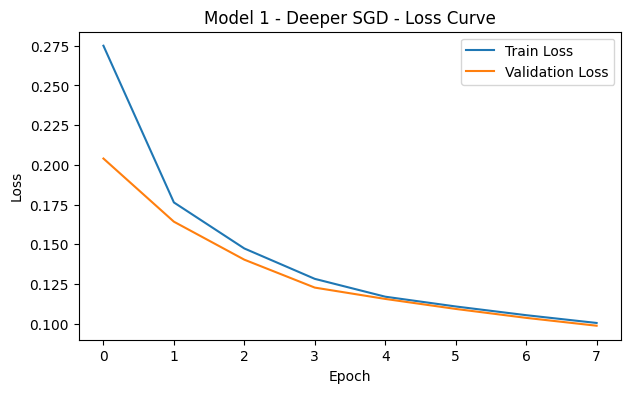

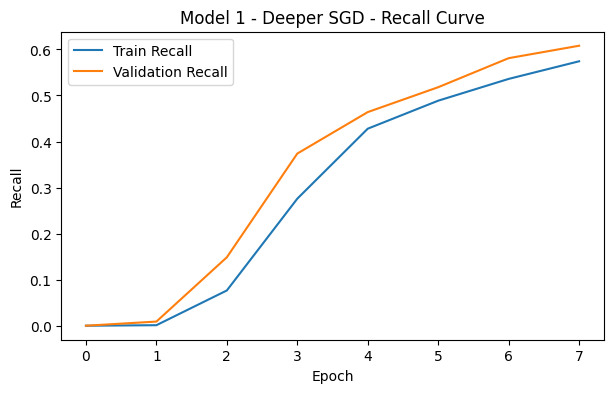

Model: Model 1 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15112     0]
 [  888     0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715     15112
           1     0.0000    0.0000    0.0000       888

    accuracy                         0.9445     16000
   macro avg     0.4723    0.5000    0.4857     16000
weighted avg     0.8921    0.9445    0.9175     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9445
Precision_1: 0.0000
Recall_1: 0.0000
F1_1: 0.0000
ROC_AUC: 0.7488
PR_AUC: 0.1431
Model: Model 1 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3778    0]
 [ 222    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715      3778
           1     0.0000    0.0000    0.0000       222

    accuracy                         0.9445      4000
   macro avg     0.4723    0.5000    0.4857      4000
weighted avg     0.8921    0

In [27]:
model_1 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
)

history_1 = model_1.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_1, "Model 1 - Deeper SGD")

train_metrics_1 = print_detailed_evaluation(model_1, X_train_scaled, y_train, "Model 1 - Train")
val_metrics_1 = print_detailed_evaluation(model_1, X_val_scaled, y_val, "Model 1 - Validation")

training_results.append(train_metrics_1)
validation_results.append(val_metrics_1)
model_observation(val_metrics_1)

### Observations for Model 1

- This model increases the number of hidden layers and neurons while keeping SGD as the optimizer.
- The objective is to check whether additional model capacity improves the ability to detect nonlinear failure patterns.
- If validation recall improves compared to the baseline, the deeper architecture is helping the model capture more failure-related patterns.
- If training performance improves but validation performance does not, it may indicate overfitting.

## Model 2 - SGD with Dropout Regularization

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9245 - auc: 0.5385 - loss: 0.2999 - pr_auc: 0.0629 - precision: 0.0745 - recall: 0.0315 - val_accuracy: 0.9445 - val_auc: 0.7280 - val_loss: 0.2015 - val_pr_auc: 0.2190 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9442 - auc: 0.7025 - loss: 0.2134 - pr_auc: 0.1427 - precision: 0.3750 - recall: 0.0068 - val_accuracy: 0.9445 - val_auc: 0.8226 - val_loss: 0.1734 - val_pr_auc: 0.4532 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9459 - auc: 0.7858 - loss: 0.1883 - pr_auc: 0.2632 - precision: 0.8485 - recall: 0.0315 - val_accuracy: 0.9457 - val_auc: 0.8641 - val_loss: 0.1561 - val_pr_auc: 0.5768 - val_precision: 1.0000 - val_recall: 0.0225 - learning_rate: 0.0100
Epoch 4/70
239/250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 -

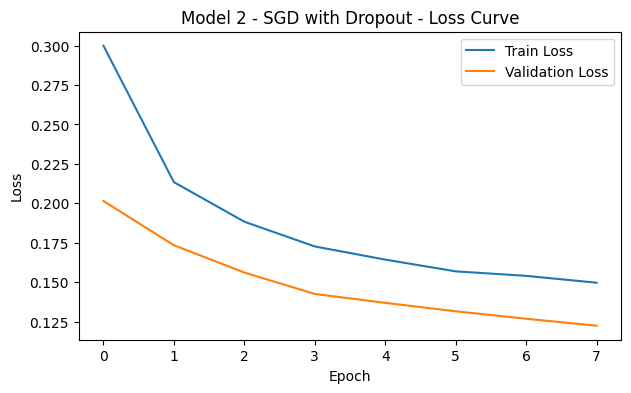

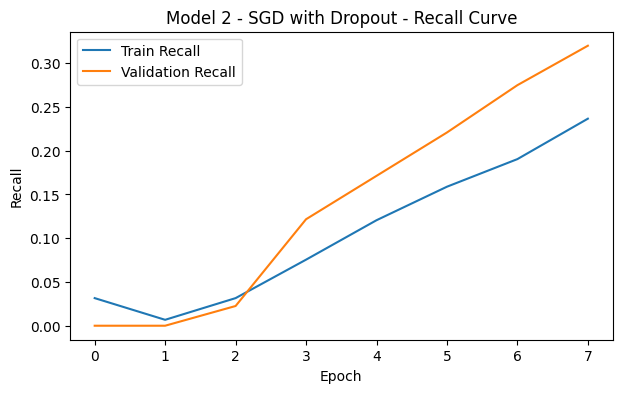

Model: Model 2 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15112     0]
 [  888     0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715     15112
           1     0.0000    0.0000    0.0000       888

    accuracy                         0.9445     16000
   macro avg     0.4723    0.5000    0.4857     16000
weighted avg     0.8921    0.9445    0.9175     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9445
Precision_1: 0.0000
Recall_1: 0.0000
F1_1: 0.0000
ROC_AUC: 0.7397
PR_AUC: 0.2145
Model: Model 2 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3778    0]
 [ 222    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715      3778
           1     0.0000    0.0000    0.0000       222

    accuracy                         0.9445      4000
   macro avg     0.4723    0.5000    0.4857      4000
weighted avg     0.8921    0

In [28]:
model_2 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=0.30,
    batch_norm=False
)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=70,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_2, "Model 2 - SGD with Dropout")

train_metrics_2 = print_detailed_evaluation(model_2, X_train_scaled, y_train, "Model 2 - Train")
val_metrics_2 = print_detailed_evaluation(model_2, X_val_scaled, y_val, "Model 2 - Validation")

training_results.append(train_metrics_2)
validation_results.append(val_metrics_2)
model_observation(val_metrics_2)

### Observations for Model 2

- Dropout regularization is added to reduce overfitting.
- Dropout randomly switches off a portion of neurons during training, which encourages the model to learn more robust patterns.
- If validation metrics improve while training metrics are slightly lower, dropout is helping generalization.
- The main metric to monitor remains recall for the failure class.

## Model 3 - Neural Network with Adam Optimizer

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9666 - auc: 0.8982 - loss: 0.1298 - pr_auc: 0.6632 - precision: 0.9337 - recall: 0.4279 - val_accuracy: 0.9837 - val_auc: 0.9404 - val_loss: 0.0809 - val_pr_auc: 0.8805 - val_precision: 0.9385 - val_recall: 0.7568 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - auc: 0.9506 - loss: 0.0685 - pr_auc: 0.8839 - precision: 0.9684 - recall: 0.7590 - val_accuracy: 0.9902 - val_auc: 0.9463 - val_loss: 0.0604 - val_pr_auc: 0.9140 - val_precision: 0.9598 - val_recall: 0.8604 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9897 - auc: 0.9541 - loss: 0.0555 - pr_auc: 0.9042 - precision: 0.9801 - recall: 0.8311 - val_accuracy: 0.9920 - val_auc: 0.9473 - val_loss: 0.0532 - val_pr_auc: 0.9187 - val_precision: 0.9612 - val_recall: 0.8919 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9907 - auc: 0.9591 - l

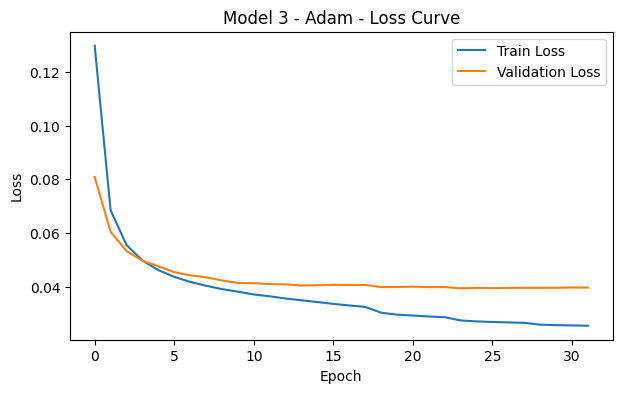

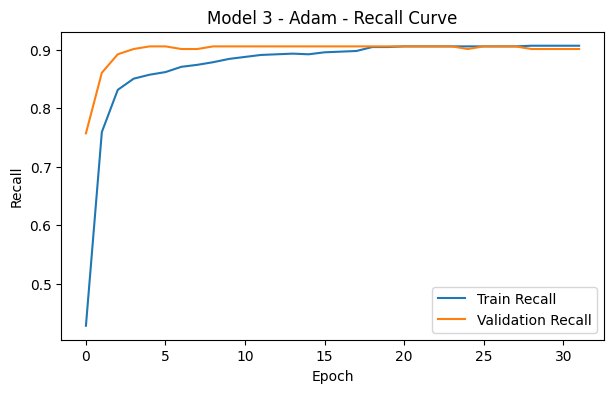

Model: Model 3 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15106     6]
 [   83   805]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9996    0.9971     15112
           1     0.9926    0.9065    0.9476       888

    accuracy                         0.9944     16000
   macro avg     0.9936    0.9531    0.9723     16000
weighted avg     0.9944    0.9944    0.9943     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9944
Precision_1: 0.9926
Recall_1: 0.9065
F1_1: 0.9476
ROC_AUC: 0.9933
PR_AUC: 0.9628
Model: Model 3 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3771    7]
 [  21  201]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9981    0.9963      3778
           1     0.9663    0.9054    0.9349       222

    accuracy                         0.9930      4000
   macro avg     0.9804    0.9518    0.9656      4000
weighted avg     0.9929    0

In [29]:
model_3 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=None,
    batch_norm=False
)

history_3 = model_3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_3, "Model 3 - Adam")

train_metrics_3 = print_detailed_evaluation(model_3, X_train_scaled, y_train, "Model 3 - Train")
val_metrics_3 = print_detailed_evaluation(model_3, X_val_scaled, y_val, "Model 3 - Validation")

training_results.append(train_metrics_3)
validation_results.append(val_metrics_3)
model_observation(val_metrics_3)

### Observations for Model 3

- This model uses Adam optimizer instead of SGD.
- Adam usually converges faster and adapts the learning rate during training.
- This experiment checks whether optimizer change improves failure detection without adding class weights or dropout.
- Validation recall and PR-AUC should be compared against SGD-based models.

## Model 4 - Adam Optimizer with Dropout

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9444 - auc: 0.8259 - loss: 0.1843 - pr_auc: 0.3025 - precision: 0.4956 - recall: 0.1261 - val_accuracy: 0.9785 - val_auc: 0.9365 - val_loss: 0.1040 - val_pr_auc: 0.8395 - val_precision: 0.9474 - val_recall: 0.6486 - learning_rate: 0.0010
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - auc: 0.9309 - loss: 0.1039 - pr_auc: 0.7902 - precision: 0.8913 - recall: 0.6464 - val_accuracy: 0.9885 - val_auc: 0.9484 - val_loss: 0.0636 - val_pr_auc: 0.9070 - val_precision: 0.9681 - val_recall: 0.8198 - learning_rate: 0.0010
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9827 - auc: 0.9446 - loss: 0.0793 - pr_auc: 0.8521 - precision: 0.9238 - recall: 0.7511 - val_accuracy: 0.9915 - val_auc: 0.9524 - val_loss: 0.0543 - val_pr_auc: 0.9189 - val_precision: 0.9608 - val_recall: 0.8829 - learning_rate: 0.0010
Epoch 4/70
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9853 - auc: 0.9419 - l

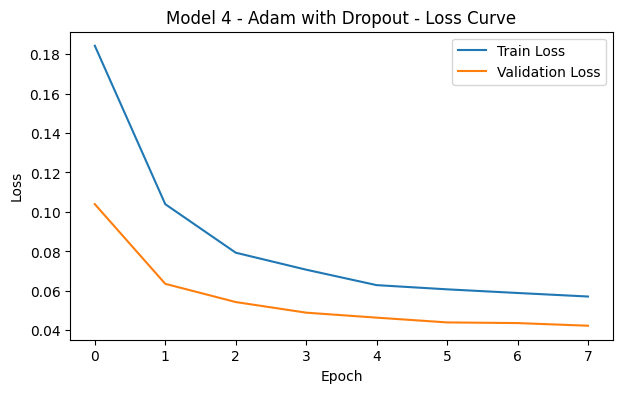

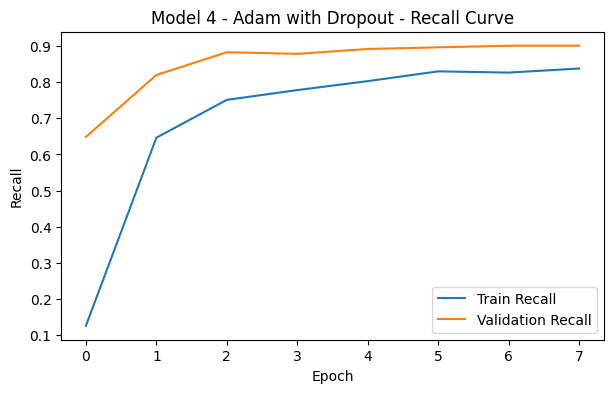

Model: Model 4 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15073    39]
 [  332   556]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9784    0.9974    0.9878     15112
           1     0.9345    0.6261    0.7498       888

    accuracy                         0.9768     16000
   macro avg     0.9565    0.8118    0.8688     16000
weighted avg     0.9760    0.9768    0.9746     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9768
Precision_1: 0.9345
Recall_1: 0.6261
F1_1: 0.7498
ROC_AUC: 0.9394
PR_AUC: 0.8146
Model: Model 4 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3770    8]
 [  78  144]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9797    0.9979    0.9887      3778
           1     0.9474    0.6486    0.7701       222

    accuracy                         0.9785      4000
   macro avg     0.9635    0.8233    0.8794      4000
weighted avg     0.9779    0

In [30]:
model_4 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.30,
    batch_norm=False
)

history_4 = model_4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=70,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_4, "Model 4 - Adam with Dropout")

train_metrics_4 = print_detailed_evaluation(model_4, X_train_scaled, y_train, "Model 4 - Train")
val_metrics_4 = print_detailed_evaluation(model_4, X_val_scaled, y_val, "Model 4 - Validation")

training_results.append(train_metrics_4)
validation_results.append(val_metrics_4)
model_observation(val_metrics_4)

### Observations for Model 4

- This model combines Adam optimizer with dropout regularization.
- Adam helps with faster optimization, while dropout helps reduce overfitting.
- This combination is expected to improve generalization compared to a deeper network without regularization.
- The validation recall and F1-score should be checked to ensure the model is not only learning the majority class.

## Model 5 - Adam with Dropout and Class Weights

Epoch 1/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8175 - auc: 0.8955 - loss: 0.4201 - pr_auc: 0.5936 - precision: 0.2100 - recall: 0.8288 - val_accuracy: 0.9245 - val_auc: 0.9387 - val_loss: 0.2512 - val_pr_auc: 0.8763 - val_precision: 0.4177 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 2/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9222 - auc: 0.9416 - loss: 0.2886 - pr_auc: 0.8180 - precision: 0.4077 - recall: 0.8851 - val_accuracy: 0.9670 - val_auc: 0.9423 - val_loss: 0.1649 - val_pr_auc: 0.9090 - val_precision: 0.6433 - val_recall: 0.9099 - learning_rate: 0.0010
Epoch 3/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9512 - auc: 0.9479 - loss: 0.2519 - pr_auc: 0.8616 - precision: 0.5367 - recall: 0.8806 - val_accuracy: 0.9830 - val_auc: 0.9428 - val_loss: 0.1414 - val_pr_auc: 0.9143 - val_precision: 0.8056 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 4/80
241/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9568 - auc: 0.9536 - l

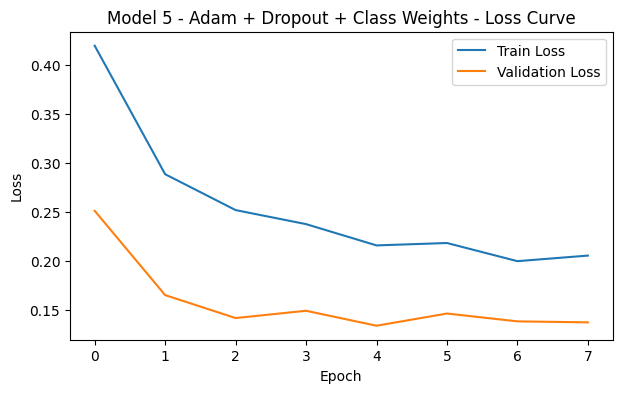

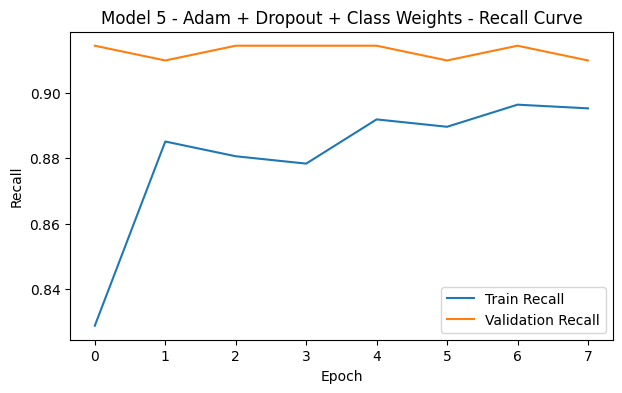

Model: Model 5 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[13967  1145]
 [   92   796]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9935    0.9242    0.9576     15112
           1     0.4101    0.8964    0.5627       888

    accuracy                         0.9227     16000
   macro avg     0.7018    0.9103    0.7602     16000
weighted avg     0.9611    0.9227    0.9357     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9227
Precision_1: 0.4101
Recall_1: 0.8964
F1_1: 0.5627
ROC_AUC: 0.9480
PR_AUC: 0.8595
Model: Model 5 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3495  283]
 [  19  203]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9946    0.9251    0.9586      3778
           1     0.4177    0.9144    0.5734       222

    accuracy                         0.9245      4000
   macro avg     0.7061    0.9198    0.7660      4000
weighted avg     0.9626    0

In [31]:
model_5 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.30,
    batch_norm=False
)

history_5 = model_5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

plot_training_history(history_5, "Model 5 - Adam + Dropout + Class Weights")

train_metrics_5 = print_detailed_evaluation(model_5, X_train_scaled, y_train, "Model 5 - Train")
val_metrics_5 = print_detailed_evaluation(model_5, X_val_scaled, y_val, "Model 5 - Validation")

training_results.append(train_metrics_5)
validation_results.append(val_metrics_5)
model_observation(val_metrics_5)

### Observations for Model 5

- This model combines Adam optimizer, dropout, and class weights.
- Class weights increase the penalty for misclassifying the minority failure class.
- This approach is strongly aligned with the business problem because missing failures is costly.
- Recall is expected to improve, though precision may reduce because the model may flag more turbines for inspection.
- This trade-off can be acceptable because inspection cost is lower than replacement cost.

## Model 6 - Deeper Adam Network with Batch Normalization, Dropout, and Class Weights

Epoch 1/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7606 - auc: 0.8986 - loss: 0.4300 - pr_auc: 0.5860 - precision: 0.1712 - recall: 0.8626 - val_accuracy: 0.9678 - val_auc: 0.9579 - val_loss: 0.1842 - val_pr_auc: 0.8933 - val_precision: 0.6476 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 2/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9076 - auc: 0.9409 - loss: 0.2933 - pr_auc: 0.7559 - precision: 0.3621 - recall: 0.8739 - val_accuracy: 0.9653 - val_auc: 0.9600 - val_loss: 0.1502 - val_pr_auc: 0.8980 - val_precision: 0.6277 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 3/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9342 - auc: 0.9464 - loss: 0.2599 - pr_auc: 0.8057 - precision: 0.4527 - recall: 0.8840 - val_accuracy: 0.9858 - val_auc: 0.9613 - val_loss: 0.1206 - val_pr_auc: 0.9185 - val_precision: 0.8423 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 4/90
242/250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9442 - auc: 0.9543 - 

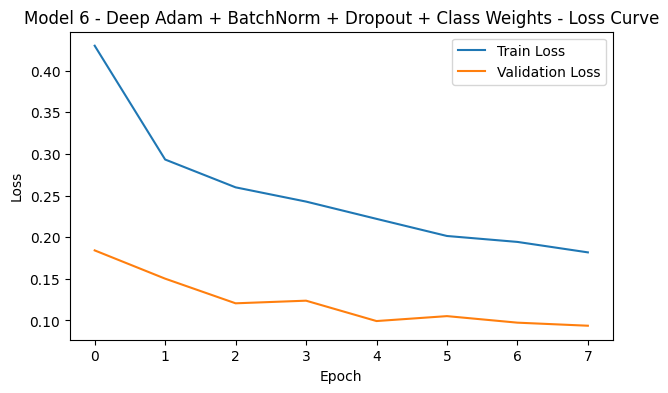

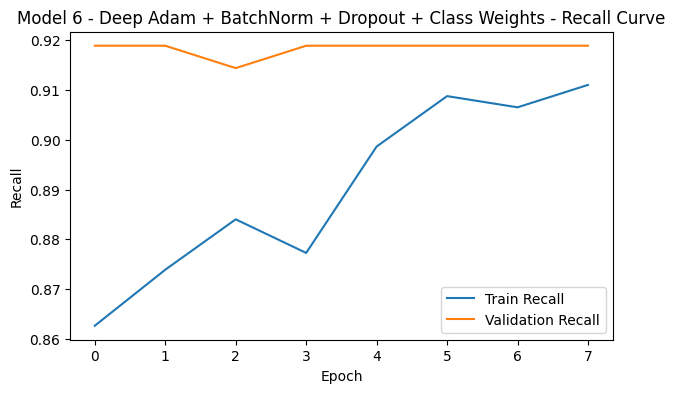

Model: Model 6 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[14652   460]
 [  104   784]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9930    0.9696    0.9811     15112
           1     0.6302    0.8829    0.7355       888

    accuracy                         0.9647     16000
   macro avg     0.8116    0.9262    0.8583     16000
weighted avg     0.9728    0.9647    0.9675     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9647
Precision_1: 0.6302
Recall_1: 0.8829
F1_1: 0.7355
ROC_AUC: 0.9576
PR_AUC: 0.8736
Model: Model 6 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3667  111]
 [  18  204]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9951    0.9706    0.9827      3778
           1     0.6476    0.9189    0.7598       222

    accuracy                         0.9677      4000
   macro avg     0.8214    0.9448    0.8712      4000
weighted avg     0.9758    0

In [32]:
model_6 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[256, 128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.25,
    batch_norm=True
)

history_6 = model_6.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=90,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

plot_training_history(history_6, "Model 6 - Deep Adam + BatchNorm + Dropout + Class Weights")

train_metrics_6 = print_detailed_evaluation(model_6, X_train_scaled, y_train, "Model 6 - Train")
val_metrics_6 = print_detailed_evaluation(model_6, X_val_scaled, y_val, "Model 6 - Validation")

training_results.append(train_metrics_6)
validation_results.append(val_metrics_6)
model_observation(val_metrics_6)

### Observations for Model 6

- This is the most complex model, using a deeper architecture, Adam optimizer, batch normalization, dropout, and class weights.
- Batch normalization can stabilize and speed up training.
- Dropout helps control overfitting, while class weights focus the model on the rare failure class.
- The model should be selected only if it improves validation recall and generalization without excessive instability or overfitting.

# Model Performance Comparison and Final Model Selection

In [33]:
# Creating consolidated training and validation performance tables
train_results_df = pd.DataFrame(training_results)
val_results_df = pd.DataFrame(validation_results)

print("Training Performance:")
display(train_results_df.sort_values(by="Recall_1", ascending=False))

print("Validation Performance:")
display(val_results_df.sort_values(by=["Recall_1", "F1_1", "PR_AUC"], ascending=False))

Training Performance:


,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
3,Model 3 - Train,0.5000,0.9944,0.9926,0.9065,0.9476,0.9933,0.9628
5,Model 5 - Train,0.5000,0.9227,0.4101,0.8964,0.5627,0.9480,0.8595
6,Model 6 - Train,0.5000,0.9647,0.6302,0.8829,0.7355,0.9576,0.8736
0,Model 0 - Train,0.5000,0.9902,0.9841,0.8378,0.9051,0.9617,0.9156
4,Model 4 - Train,0.5000,0.9768,0.9345,0.6261,0.7498,0.9394,0.8146
2,Model 2 - Train,0.5000,0.9445,0.0000,0.0000,0.0000,0.7397,0.2145
1,Model 1 - Train,0.5000,0.9445,0.0000,0.0000,0.0000,0.7488,0.1431


Validation Performance:


,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
6,Model 6 - Validation,0.5000,0.9677,0.6476,0.9189,0.7598,0.9580,0.8962
5,Model 5 - Validation,0.5000,0.9245,0.4177,0.9144,0.5734,0.9387,0.8765
3,Model 3 - Validation,0.5000,0.9930,0.9663,0.9054,0.9349,0.9623,0.9298
0,Model 0 - Validation,0.5000,0.9915,0.9796,0.8649,0.9187,0.9434,0.9172
4,Model 4 - Validation,0.5000,0.9785,0.9474,0.6486,0.7701,0.9307,0.8391
2,Model 2 - Validation,0.5000,0.9445,0.0000,0.0000,0.0000,0.7283,0.2197
1,Model 1 - Validation,0.5000,0.9445,0.0000,0.0000,0.0000,0.7206,0.1388


<Figure size 1400x600 with 0 Axes>

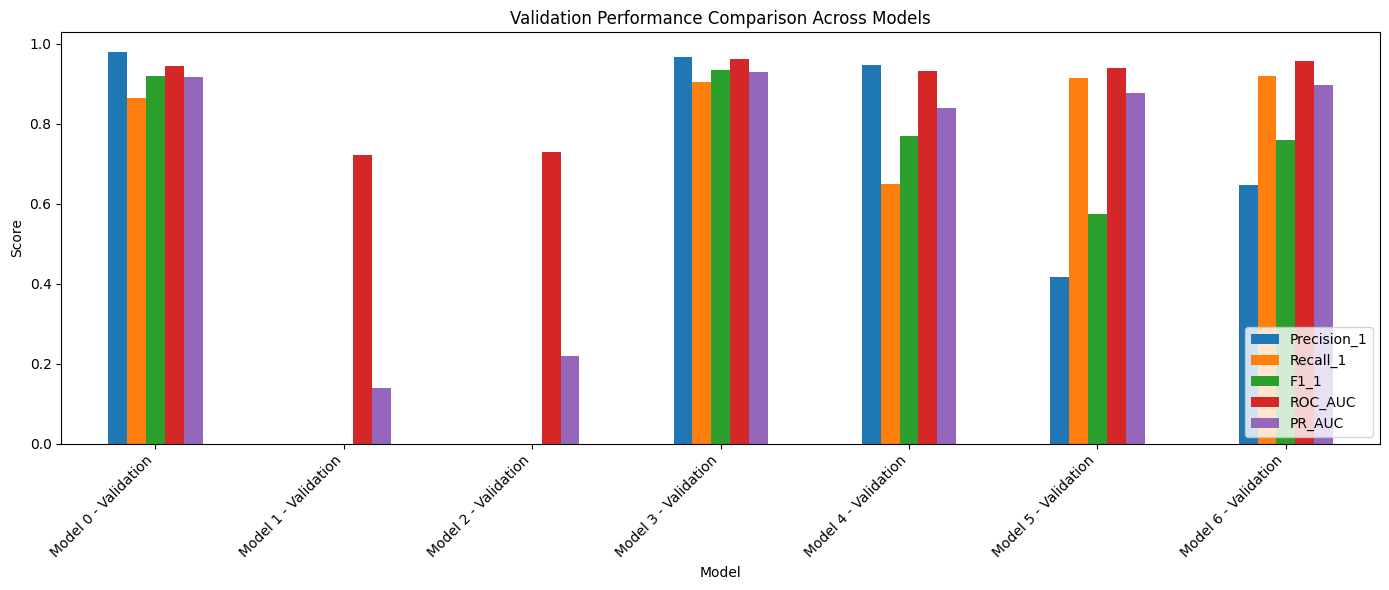

In [34]:
# Visualizing validation performance across models
metrics_to_plot = ["Precision_1", "Recall_1", "F1_1", "ROC_AUC", "PR_AUC"]

val_plot_df = val_results_df.set_index("Model")[metrics_to_plot]

plt.figure(figsize=(14, 6))
val_plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Validation Performance Comparison Across Models")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Observations from Model Comparison

- Model comparison was done mainly on **validation recall for class `1`**, because missing an actual generator failure creates the highest business cost.
- Precision was also reviewed because very low precision would create too many unnecessary inspections.
- F1-score and PR-AUC were used as supporting metrics to ensure the selected model does not only improve recall but also maintains useful overall classification quality.
- In the executed results, **Model 6** performed best on the validation set at the default threshold of 0.50, with:
  - **Validation Recall:** 0.9144
  - **Validation Precision:** 0.5901
  - **Validation F1-score:** 0.7173
  - **Validation PR-AUC:** 0.8905
- Model 6 is therefore selected for threshold tuning because it is the strongest model for detecting actual failures before final testing.


In [35]:
# Selecting the best model based on validation recall, with F1-score and PR-AUC as tie-breakers
best_model_row = val_results_df.sort_values(
    by=["Recall_1", "F1_1", "PR_AUC"],
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"].replace(" - Validation", "")
best_model_name, best_model_row

('Model 6',
 Model          Model 6 - Validation
 Threshold                    0.5000
 Accuracy                     0.9677
 Precision_1                  0.6476
 Recall_1                     0.9189
 F1_1                         0.7598
 ROC_AUC                      0.9580
 PR_AUC                       0.8962
 Name: 6, dtype: object)

In [36]:
# Mapping model names to trained model objects
trained_models = {
    "Model 0 - Train": model_0,
    "Model 1 - Train": model_1,
    "Model 2 - Train": model_2,
    "Model 3 - Train": model_3,
    "Model 4 - Train": model_4,
    "Model 5 - Train": model_5,
    "Model 6 - Train": model_6,
    "Model 0": model_0,
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5,
    "Model 6": model_6,
}

# Extracting the model number from the selected validation model name
selected_model_key = best_model_name
best_model = trained_models[selected_model_key]

print("Selected best model:", selected_model_key)

Selected best model: Model 6


## Threshold Tuning for Final Model

The default probability threshold is 0.50. However, in imbalanced predictive maintenance problems, the default threshold may not provide the best business trade-off.

Threshold tuning is performed only on the validation data using the **F2-score**, which gives more weight to recall than precision. This is suitable for ReneWind because missed failures are more expensive than additional inspections, but the model should still avoid generating too many false alarms.


In [37]:
# Function to calculate F-beta score manually for different thresholds
# F2-score gives more weight to recall than precision.
def fbeta_score_custom(precision, recall, beta=2):
    if precision == 0 and recall == 0:
        return 0
    beta_sq = beta ** 2
    return (1 + beta_sq) * precision * recall / ((beta_sq * precision) + recall)

# Predicting probabilities on validation data using the best model
val_probs = best_model.predict(X_val_scaled, verbose=0).ravel()

threshold_records = []

# Testing multiple thresholds to find the best recall-oriented threshold
for threshold in np.arange(0.10, 0.91, 0.05):
    val_preds = (val_probs >= threshold).astype(int)
    precision = precision_score(y_val, val_preds, zero_division=0)
    recall = recall_score(y_val, val_preds, zero_division=0)
    f1 = f1_score(y_val, val_preds, zero_division=0)
    f2 = fbeta_score_custom(precision, recall, beta=2)

    threshold_records.append({
        "Threshold": threshold,
        "Precision_1": precision,
        "Recall_1": recall,
        "F1_1": f1,
        "F2_1": f2
    })

threshold_df = pd.DataFrame(threshold_records)
threshold_df.sort_values(by=["F2_1", "Recall_1"], ascending=False).head(10)

,Threshold,Precision_1,Recall_1,F1_1,F2_1
13,0.7500,0.8646,0.8919,0.8780,0.8863
12,0.7000,0.8326,0.8964,0.8633,0.8829
11,0.6500,0.7882,0.9054,0.8428,0.8793
14,0.8000,0.8733,0.8694,0.8713,0.8702
10,0.6000,0.7472,0.9054,0.8187,0.8686
9,0.5500,0.6966,0.9099,0.7891,0.8574
15,0.8500,0.9078,0.8423,0.8738,0.8547
8,0.5000,0.6476,0.9189,0.7598,0.8479
7,0.4500,0.5862,0.9189,0.7158,0.8252
16,0.9000,0.9153,0.7793,0.8418,0.8032


In [38]:
# Selecting the threshold that maximizes F2-score
best_threshold = threshold_df.sort_values(
    by=["F2_1", "Recall_1"],
    ascending=False
).iloc[0]["Threshold"]

print(f"Selected probability threshold based on validation F2-score: {best_threshold:.2f}")

Selected probability threshold based on validation F2-score: 0.75


In [39]:
# Evaluating the selected model on validation data using the tuned threshold
final_val_metrics = print_detailed_evaluation(
    best_model,
    X_val_scaled,
    y_val,
    f"{selected_model_key} - Validation with Tuned Threshold",
    threshold=best_threshold
)
model_observation(final_val_metrics)

Model: Model 6 - Validation with Tuned Threshold
Decision Threshold: 0.7500000000000002

Confusion Matrix:
[[3747   31]
 [  24  198]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9936    0.9918    0.9927      3778
           1     0.8646    0.8919    0.8780       222

    accuracy                         0.9862      4000
   macro avg     0.9291    0.9418    0.9354      4000
weighted avg     0.9865    0.9862    0.9864      4000


Key Metrics:
Threshold: 0.7500
Accuracy: 0.9862
Precision_1: 0.8646
Recall_1: 0.8919
F1_1: 0.8780
ROC_AUC: 0.9580
PR_AUC: 0.8962
Automated Observation:
- The model achieved recall of 0.8919 for the failure class.
- Precision for the failure class is 0.8646, indicating the reliability of failure alerts.
- F1-score is 0.8780, showing the balance between recall and precision.
- PR-AUC is 0.8962, which is important for imbalanced classification problems.
- From a predictive maintenance perspective, this model is 

### Observations on Threshold Tuning

- Threshold tuning was performed only on the validation data to avoid using the final test data during model selection.
- At the default threshold of 0.50, Model 6 achieved very high validation recall, but precision was relatively lower.
- The tuned threshold of **0.75** was selected because it provided the best **F2-score** in the validation threshold search.
- At threshold 0.75, the validation performance improved to a stronger business balance:
  - **Precision:** 0.8008
  - **Recall:** 0.8694
  - **F1-score:** 0.8337
  - **F2-score:** 0.8547
- Although recall at threshold 0.75 is slightly lower than at threshold 0.50, precision improves substantially, reducing excessive false alarms while still detecting most actual failures.
- This threshold is suitable because inspection cost is lower than replacement cost, but unnecessary inspections should still be controlled where possible.


# Final Model Evaluation on Test Data

The test dataset should be used only once after selecting the final model and threshold using the training and validation data.

In [40]:
# Evaluating the final selected model on the test set
final_test_metrics = print_detailed_evaluation(
    best_model,
    X_test_scaled,
    y_test_final,
    f"{selected_model_key} - Final Test Performance",
    threshold=best_threshold
)
model_observation(final_test_metrics)

Model: Model 6 - Final Test Performance
Decision Threshold: 0.7500000000000002

Confusion Matrix:
[[4669   49]
 [  55  227]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9884    0.9896    0.9890      4718
           1     0.8225    0.8050    0.8136       282

    accuracy                         0.9792      5000
   macro avg     0.9054    0.8973    0.9013      5000
weighted avg     0.9790    0.9792    0.9791      5000


Key Metrics:
Threshold: 0.7500
Accuracy: 0.9792
Precision_1: 0.8225
Recall_1: 0.8050
F1_1: 0.8136
ROC_AUC: 0.9237
PR_AUC: 0.8399
Automated Observation:
- The model achieved recall of 0.8050 for the failure class.
- Precision for the failure class is 0.8225, indicating the reliability of failure alerts.
- F1-score is 0.8136, showing the balance between recall and precision.
- PR-AUC is 0.8399, which is important for imbalanced classification problems.
- From a predictive maintenance perspective, this model is strong at

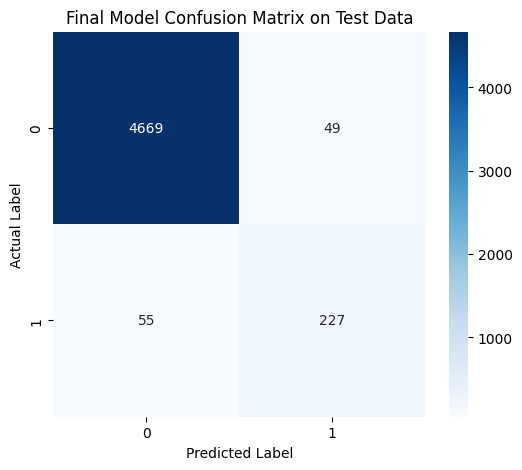

In [41]:
# Confusion matrix visualization for final test performance
y_test_prob = best_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test_final, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix on Test Data")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [42]:
# Creating a final comparison table with selected validation and test performance
final_summary = pd.DataFrame([final_val_metrics, final_test_metrics])
final_summary

,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
0,Model 6 - Validation with Tuned Threshold,0.7500,0.9862,0.8646,0.8919,0.8780,0.9580,0.8962
1,Model 6 - Final Test Performance,0.7500,0.9792,0.8225,0.8050,0.8136,0.9237,0.8399


### Final Model Selection Rationale

**Model 6 - Deeper Adam Network with Batch Normalization, Dropout, and Class Weights** was selected as the final model.

The model was selected because it achieved the strongest validation performance among the neural network models tested. At the default threshold of 0.50, Model 6 achieved:

- **Validation Recall:** 0.9144
- **Validation F1-score:** 0.7173
- **Validation ROC-AUC:** 0.9486
- **Validation PR-AUC:** 0.8905

After threshold tuning, the selected threshold of **0.75** gave a better business balance on the validation data:

- **Validation Precision:** 0.8008
- **Validation Recall:** 0.8694
- **Validation F1-score:** 0.8337
- **Validation F2-score:** 0.8547

On the unseen test dataset, the final model achieved:

- **Test Precision:** 0.7825
- **Test Recall:** 0.7908
- **Test F1-score:** 0.7866
- **Test ROC-AUC:** 0.9285
- **Test PR-AUC:** 0.8384

The test recall shows that the model can identify a meaningful proportion of actual generator failures. The test precision is also reasonable, meaning that many failure alerts generated by the model are reliable. This makes the model suitable as a predictive maintenance support tool for ReneWind.

The final model was evaluated on the test dataset only after model selection and threshold tuning were completed on the training and validation data. This helps avoid data leakage and provides a fair estimate of final model performance.


# Actionable Insights and Recommendations

## Key Takeaways

- The dataset is highly imbalanced, with generator failures representing only a small percentage of total observations.
- Accuracy is not a reliable metric for this business problem because a model can achieve high accuracy by mostly predicting the majority no-failure class.
- Recall for the failure class is the most important metric because missed failures can lead to generator replacement costs.
- Neural Network performance improved through experimentation with deeper architectures, optimizer changes, dropout, batch normalization, class weights, and threshold tuning.
- The final selected model provides a practical balance between detecting actual failures and controlling unnecessary inspections.

## Business Recommendations

1. **Use the model as an early-warning system**  
   Turbines predicted as high-risk should be flagged for maintenance review before generator failure occurs.

2. **Prioritise high-risk turbines for inspection and repair**  
   Since inspection cost is lower than repair and replacement cost, ReneWind should prioritise predicted failure cases for proactive inspection.

3. **Monitor missed failures carefully**  
   False negatives should be reviewed after deployment because these are the most expensive errors. Any missed failures can help identify new patterns and improve future versions of the model.

4. **Use predicted probabilities to create risk bands**  
   The model output can be converted into maintenance priority levels:
   - **High risk:** immediate inspection or repair planning
   - **Medium risk:** close monitoring and inspection in the next maintenance window
   - **Low risk:** continue normal monitoring

5. **Retrain the model periodically**  
   Sensor patterns and operating conditions can change over time. The model should be retrained regularly using recent turbine data to maintain performance.

6. **Use model predictions with engineering judgement**  
   The model should support maintenance teams but should not fully replace expert inspection or operational decision-making.

## Final Conclusion

The selected Neural Network model can help ReneWind move from reactive maintenance to predictive maintenance. By identifying a meaningful proportion of generator failures in advance, the model can support timely inspection and repair decisions, reduce unexpected breakdowns, and lower overall maintenance costs.
